# Connection with diffusion models
> Notebook extrait de `baseline_torch.ipynb`. Cette section illustre le lien entre le processus de diffusion SPDE (avant/arrière) et les modèles de diffusion génératifs.

## 1. Torch utilities (prérequis)

In [2]:
import os 
import torch
import torch.distributions as tdist
from torch.utils.dlpack import to_dlpack
from torch.utils.dlpack import from_dlpack
rnorm = tdist.Normal(torch.tensor([0.]), torch.tensor([1]))
from torch.autograd import Function
import numpy as np
from sksparse.cholmod import cholesky
import scipy.sparse as scsp
from math import sqrt 
from torch_sparse.tensor import SparseTensor
from torch_sparse.matmul import matmul as matmul2
import cupy
from cupyx.scipy.sparse.linalg import spsolve as cupy_spsolve
from cupyx.scipy.sparse import csc_matrix as cupy_sp_csc_matrix
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from IPython.display import Image
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Scipy_SolveCholesky(Function):
# Cholesky decomposition of sparse matrices

    @staticmethod
    def forward(self, torch_sparsematrix, dt, perm=False):
        # cast torch_sparsematrix to scipy sparse csc matrix 
        sp_sparsematrix = scsp.csc_matrix((torch_sparsematrix.detach().cpu().coalesce().values(),
                                           torch_sparsematrix.detach().cpu().coalesce().indices()),
                                          shape=(torch_sparsematrix.shape[0],torch_sparsematrix.shape[0]))

        A = scsp.identity(sp_sparsematrix.shape[0])+\
            (dt* sp_sparsematrix) 
        
        # Cholesky decomposition with permutation A=P'LL'P
        if perm==True:
            AspChol = cholesky(A)
            # save input requires for backward (A here from Ax=b) and
            self.save_for_backward( torch.tensor(AspChol.P()), torch.tensor(AspChol.L()) )
        else:
            # Cholesky decomposition without permutation A=L'L
            AspChol = cholesky(A,ordering_method="natural")
            # save input requires for backward (A here from Ax=b) and
            Lcoo = AspChol.L().tocoo()
            L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),
                                                torch.FloatTensor(Lcoo.data))
            self.save_for_backward(L)

        return torch.as_tensor(L, dtype=torch_sparsematrix.dtype)
    
def sparse_eye(size, val = torch.tensor(1.0)):
    """
    Returns the identity matrix as a sparse matrix
    """
    indices = torch.arange(0, size).long().unsqueeze(0).expand(2, size)
    if len(val.size())==0:
        values = (val.expand(size))
    else:
        values = val.to(device)
    cls = getattr(torch.sparse, values.type().split(".")[-1])
    return cls(indices, values, torch.Size([size, size]))

def sparse_repeat(size,n1,n2):
    """
    Returns a sparse zero-filled tensor repeating 
    a 2D size*size sparse zero-filled tensor
    n1 times along dim1 and n2 times along n2
    """
    return torch.sparse.FloatTensor(size*n1,size*n2)

def spspmm(A,B):
    indexA = A.detach().cpu().coalesce().indices()
    valueA = A.detach().cpu().coalesce().values()
    indexB = B.detach().cpu().coalesce().indices()
    valueB = B.detach().cpu().coalesce().values()
    m = A.size()[0]
    k = A.size()[1]
    n = B.size()[1]

    coalesced = True

    A2 = SparseTensor(row=indexA[0], col=indexA[1], value=valueA,
                     sparse_sizes=(m, k), is_sorted=not coalesced)
    B2 = SparseTensor(row=indexB[0], col=indexB[1], value=valueB,
                     sparse_sizes=(k, n), is_sorted=not coalesced)
    
    C = matmul2(A2, B2)
    row, col, value = C.coo()
    indexC = torch.stack([row, col], dim=0)
    valueC = value

    return torch.sparse.FloatTensor(indexC.long(), valueC, torch.Size([m,n]))

def pow_diff_operator(A,pow):
    B = A
    if pow>1:
      for _ in range(pow-1):
        B = spspmm(B,A)  
    return B

## 2. Paramètres de simulation

In [3]:
# Domain size
resolution = 10
nx = int(12.8 * resolution)
ny = int(12.8 * resolution)
nb_nodes = nx * ny
# x, y and time lag
dx = 1
dy = 1
dt = 0.25
# kappa
kappa = 1/3
pow = 1
# Simulation total time
tps = 100
n_iter = int(tps / dt)
n_iter = 500

## 3. Opérateurs de diffusion et Cholesky

In [4]:
def diff_operator(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny
    H11=H[0,0] ; H12=H[0,1] ; H21=H[1,0] ; H22=H[0,1]  
    
    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H11/(dx**2) + H22/(dy**2))).repeat_interleave(N) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))


def diff_operator2(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny

    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H[0,0,index]/(dx**2) + H[1,1,index]/(dy**2))) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))


def power_iter_sparse(M_sp, n_iter=80):
    """Estimate largest eigenvalue of a sparse matrix via power iteration."""
    n = M_sp.shape[0]
    v = torch.randn(n, device=M_sp.device, dtype=M_sp.dtype)
    v = v / v.norm()
    for _ in range(n_iter):
        v = torch.mv(M_sp, v)
        nrm = v.norm()
        if nrm < 1e-30:
            break
        v = v / nrm
    lam = torch.dot(v, torch.mv(M_sp, v)).item()
    return lam

In [5]:
# ── Tenseur de diffusion local (anisotropie locale) ──────────────────────────
def fxy(x,y):
    return( ((2*resolution)/np.pi)*( (3/4)*np.sin(2*np.pi*x/(5*resolution))) + (1/4)*np.sin(2*np.pi*y/(5*resolution) ))

x_grid, y_grid = np.meshgrid(range(nx),range(ny))
res = np.array(fxy(x_grid, y_grid))
grad = np.gradient(res)
u_ = grad[0]
v_ = grad[1]

def rotate_vector(x1, y1, angle):
    x1_ = x1.flatten()
    y1_ = y1.flatten()
    x2_ = np.cos(angle)*x1_ - np.sin(angle)*y1_
    y2_ = np.sin(angle)*x1_ + np.cos(angle)*y1_
    return np.c_[x2_, y2_]

u = np.transpose(np.reshape(np.array(rotate_vector(u_, v_, -np.pi/2)[:,0]), (nx, ny)))
v = np.transpose(np.reshape(np.array(rotate_vector(u_, v_, -np.pi/2)[:,1]), (nx, ny)))

def diffusion_tensor(u, v, gamma, beta):
    nb_nodes = u.shape[0]*u.shape[1]
    H = np.zeros((2, 2, nb_nodes))
    cpt = 0
    for i in range(u.shape[0]):
        for j in range(u.shape[1]):
            vs = np.r_[u[i,j], v[i,j]].reshape((2,1))
            Hs = (gamma*np.eye(2)) + beta*(vs @ vs.T)
            H[:,:,cpt] = Hs
            cpt = cpt + 1
    return H

H_ = torch.from_numpy(diffusion_tensor(u, v, 1, 25)).float()

# ── Opérateur de diffusion B et décomposition de Cholesky ────────────────────
pow = 2
dt = 1
A = diff_operator2(nx, ny, dx, dy, H=H_, kappa=1./3)
B = A
L = Scipy_SolveCholesky.apply(B, dt)
print("Opérateur de diffusion B et facteur de Cholesky L calculés.")

/tmp/ipykernel_2633008/3297496472.py:107: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:653.)
  return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))


Opérateur de diffusion B et facteur de Cholesky L calculés.


/tmp/ipykernel_2633008/3765395567.py:48: UserWarning: torch.sparse.SparseTensor(indices, values, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),


In [6]:
def build_simulation_solver(L_sparse):
    """
    Pré-calcule L_dense et L_dense^T à partir du facteur de Cholesky creux.
    À appeler UNE SEULE FOIS, résultat réutilisé à chaque pas de simulation.
    """
    L_d  = torch.tril(L_sparse.to_dense()).float()
    L_dT = L_d.T.contiguous()
    return L_d, L_dT


def run_simulation_fast(n_steps, L_dense, L_denseT, x0=None,
                        dt=1.0, dx=1, dy=1, nb_nodes=None,
                        device=torch.device('cpu')):
    """
    Génère n_steps pas de la simulation SPDE implicite.
    x_{t+1} = (L L^T)^{-1} (x_t + σ·ε)    où L L^T = I + dt·B
    """
    if nb_nodes is None:
        nb_nodes = L_dense.shape[0]

    sigma = float(np.sqrt(dt / (dx * dy)))
    states = torch.empty((n_steps, nb_nodes), dtype=torch.float32)
    x_cur = (x0 if x0 is not None else torch.randn(nb_nodes)).float()

    L_d  = L_dense.to(device)
    L_dT = L_denseT.to(device)

    for i in range(n_steps):
        rhs = x_cur + sigma * torch.randn(nb_nodes, device=device)
        z = torch.linalg.solve_triangular(L_d, rhs.unsqueeze(1), upper=False)
        x_cur = torch.linalg.solve_triangular(L_dT, z, upper=True).squeeze(1)
        states[i] = x_cur.cpu()

    return states

---
# Connection with diffusion models

Cette section établit le lien entre le processus de diffusion SPDE (Euler implicite) et les modèles de diffusion génératifs (score-based / DDPM).

Le processus **forward** correspond à la simulation SPDE :
$$\mathbf{x}_{t+dt} = \mathbf{M}(\mathbf{x}_t + \sigma\sqrt{dt}\,\mathbf{w}_t), \quad \mathbf{M}=(\mathbf{I}+dt\,\mathbf{B})^{-1}$$

Le processus **reverse** utilise le score $\nabla_x \log p(\mathbf{x}_t)$ pour remonter le processus stochastique.

In [7]:
%matplotlib inline

import torch
import matplotlib.pyplot as plt
import time

torch.set_default_dtype(torch.float32)

# ─────────────────────────────────────────────────────────────────────────────
# Paramètres
# ─────────────────────────────────────────────────────────────────────────────
nsteps  = 10
nbNodes = nx * ny
dt      = 0.1
sigma   = 0.3

# ─────────────────────────────────────────────────────────────────────────────
# Pré-calcul des matrices
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── (1) Opérateur de diffusion A (creux) ──────────────────────────────────────
_A_sp   = diff_operator2(nx, ny, dx, dy, H_, 0.33)

# ── (2) Facteur de Cholesky de (I + dt·A) ────────────────────────────────────
_L_chol = Scipy_SolveCholesky.apply(_A_sp, dt)
_L_d    = torch.tril(_L_chol.to_dense()).float()
_L_dT   = _L_d.T.contiguous()
print(f"Cholesky de (I+dt·A) calculé  [{time.perf_counter()-t0:.1f}s]")

# ── (3) Matrice de transition M = (I + dt·A)^{-1} ────────────────────────────
Id_dense = torch.eye(nbNodes).float()
_M_tmp   = torch.linalg.solve_triangular(_L_d,  Id_dense, upper=False)
_M       = torch.linalg.solve_triangular(_L_dT, _M_tmp,   upper=True)
print(f"M calculé  [{time.perf_counter()-t0:.1f}s]")

# ── (4) Covariance du bruit incrémental Q ─────────────────────────────────────
# Forward :  x_{t+1} = M (x_t + noise_scale * eps)  = M x_t + noise_scale*M*eps
#                     => bruit effectif = noise_scale * M * eps
#                     => Q = noise_scale^2 * M M^T
_noise_scale = float(sigma * (dt / (dx * dy)) ** 0.5)
_MMT         = _M @ _M.T                          # M M^T  (constant)
_Q           = (_noise_scale ** 2) * _MMT         # covariance incrémentale
print(f"Q calculé  (noise_scale={_noise_scale:.5f})  [{time.perf_counter()-t0:.1f}s]")

# ── (5) Séquence de covariances P_t  (P_0 = I, récursion forward) ─────────────
# P_{t+1} = M P_t M^T + Q   avec P_0 = I
# Note : M est une forte contraction (dt petit + A à spectre positif),
# donc P_t décroît de P_0=I vers la variance stationnaire P∞ << I.
# C'est NORMAL que le reverse remonte la variance de P∞ vers I.
_P_list = [Id_dense.clone()]
for k in range(1, nsteps + 1):
    _P_list.append(_M @ _P_list[-1] @ _M.T + _Q)

print(f"std(P_0)       = {_P_list[0].diag().sqrt().mean().item():.4f}  (= 1 par construction)")
print(f"std(P_{nsteps})       = {_P_list[nsteps].diag().sqrt().mean().item():.4f}  (variance à t=nsteps)")
print(f"Setup total : {time.perf_counter()-t0:.2f}s")

# ─────────────────────────────────────────────────────────────────────────────
# Forward diffusion
# ─────────────────────────────────────────────────────────────────────────────
def run_simulation_diffusion_fast(nsteps):
    """
    Forward : x_{t+1} = M (x_t + noise_scale * eps)
    x_0 ~ N(0, I)  (bruit blanc unité)
    """
    x0     = torch.randn(nbNodes, 1)
    Z_list = [x0]
    t_fwd  = time.perf_counter()

    for i in range(nsteps):
        eps = torch.randn(nbNodes, 1)
        rhs = _noise_scale * eps + Z_list[i]
        Z = torch.linalg.solve_triangular(_L_d,  rhs, upper=False)
        Z = torch.linalg.solve_triangular(_L_dT, Z,   upper=True)
        Z_list.append(Z)

    print(f"Forward {nsteps} pas : {time.perf_counter()-t_fwd:.3f}s")
    print(f"  std x_0  = {Z_list[0].std().item():.3f}  (attendu ≈ 1.0 = sqrt(diag P_0))")
    print(f"  std x_{nsteps} = {Z_list[-1].std().item():.3f}  (attendu ≈ {_P_list[nsteps].diag().sqrt().mean().item():.3f} = sqrt(diag P_{nsteps}))")
    return Z_list, _P_list


Cholesky de (I+dt·A) calculé  [1.2s]
M calculé  [5.6s]
M calculé  [5.6s]
Q calculé  (noise_scale=0.09487)  [33.4s]
Q calculé  (noise_scale=0.09487)  [33.4s]
std(P_0)       = 1.0000  (= 1 par construction)
std(P_10)       = 0.1547  (variance à t=nsteps)
Setup total : 611.71s
std(P_0)       = 1.0000  (= 1 par construction)
std(P_10)       = 0.1547  (variance à t=nsteps)
Setup total : 611.71s


In [8]:
import time

# ── Forward diffusion ─────────────────────────────────────────────────────────
t0 = time.perf_counter()
Z_all, P_all = run_simulation_diffusion_fast(nsteps=10)
print(f"Forward total : {time.perf_counter()-t0:.3f}s")


Forward 10 pas : 0.285s
  std x_0  = 0.990  (attendu ≈ 1.0 = sqrt(diag P_0))
  std x_10 = 0.158  (attendu ≈ 0.155 = sqrt(diag P_10))
Forward total : 0.288s


In [9]:
# Z_all : liste → tensor (nsteps+1, nbNodes, 1)
# P_all : liste Python de tensors (n×n) — ne pas stacker (≈ 32 GB RAM)
Z_all = torch.stack(Z_all, dim=0)   # shape (nsteps+1, nbNodes, 1)
print(f"Z_all shape : {Z_all.shape}  |  P_all : liste de {len(P_all)} matrices {P_all[0].shape}")


Z_all shape : torch.Size([11, 16384, 1])  |  P_all : liste de 11 matrices torch.Size([16384, 16384])


In [10]:
import xarray as xr
# Z_all shape: (nsteps+1, nbNodes, 1)  →  reshape en (nsteps+1, nx, ny)
data = xr.Dataset(
    coords={'lon': np.arange(nx), 'lat': np.arange(ny),
            'time': np.arange(Z_all.shape[0])},
    data_vars={'gp': (('time', 'lat', 'lon'),
                      Z_all.detach().numpy().reshape(Z_all.shape[0], nx, ny))}
)

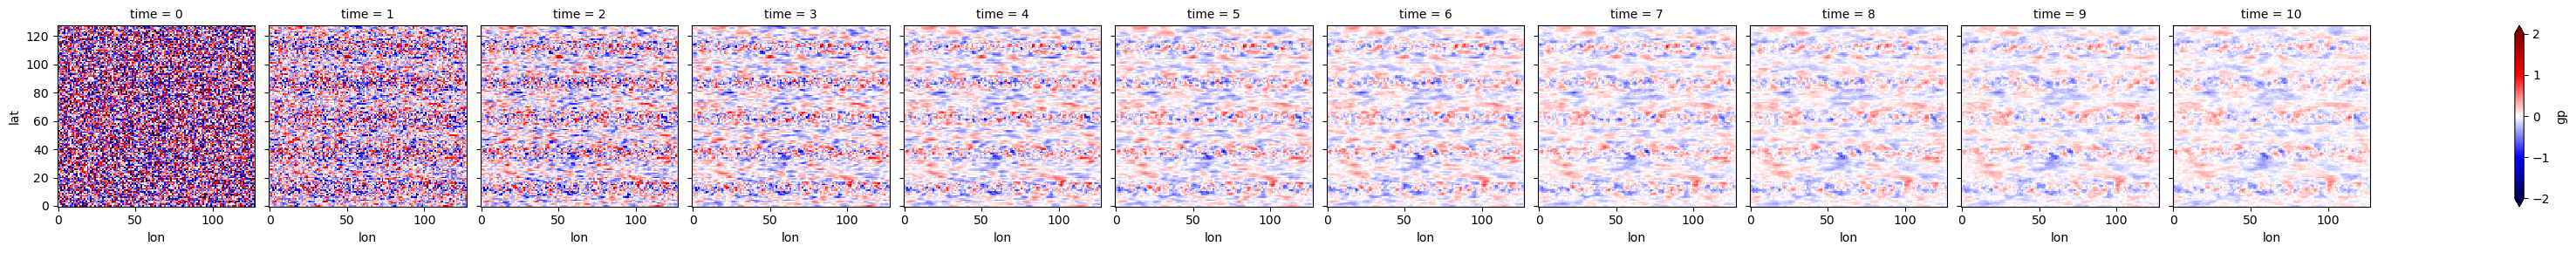

In [11]:
data.gp.plot(col='time', col_wrap=nsteps+1, vmin=-2, vmax=2, cmap=plt.cm.seismic)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Reverse process — formule exacte gaussienne (Kalman smoother)
# ─────────────────────────────────────────────────────────────────────────────
#
# Forward: x_{t+1} = M x_t + T_fwd eps_t,   T_fwd = noise_scale * M
#   => p(x_{t+1} | x_t) = N(M x_t,  Q)  avec Q = T_fwd T_fwd^T
#   => p(x_t)            = N(0, P_t)
#
# Reverse EXACT (décomposition gaussienne, sans approximation SDE) :
#   p(x_{t-1} | x_t) = N(G_t x_t,  Sigma_back_t)
#
# avec:
#   G_t         = P_{t-1} M^T P_t^{-1}           (gain de lissage)
#   Sigma_back  = P_{t-1} - G_t M P_{t-1}
#               = P_{t-1} (I - M^T P_t^{-1} M P_{t-1})
#
# Cette formule est exacte pour tout dt — pas d'approximation de Euler-Maruyama.
# ─────────────────────────────────────────────────────────────────────────────

import time

# Pré-calculer les Cholesky de chaque P_t pour le reverse
t_chol = time.perf_counter()
_ridge  = 1e-6
L_P_all = []
for k in range(nsteps + 1):
    Pk = _P_list[k]
    try:
        L_P_all.append(torch.linalg.cholesky(Pk + _ridge * Id_dense))
    except torch.linalg.LinAlgError:
        L_P_all.append(torch.linalg.cholesky(Pk + 1e-4 * Id_dense))
print(f"Cholesky de P_0…P_{nsteps} : {time.perf_counter()-t_chol:.2f}s")


def reverse_step_exact(xt, L_Pt, P_prev, L_Pprev):
    """
    Un pas exact du reverse gaussien  t → t-1.

    p(x_{t-1} | x_t) = N(G_t x_t, Sigma_back)

    G_t        = P_{t-1} M^T P_t^{-1}
    Sigma_back = P_{t-1} - G_t M P_{t-1}
    """
    # ── Gain G_t x_t = P_{t-1} M^T (P_t^{-1} x_t) ─────────────────────────
    # Étape 1 : y = P_t^{-1} x_t  via Cholesky de P_t
    y   = torch.linalg.solve_triangular(L_Pt,    xt, upper=False)
    y   = torch.linalg.solve_triangular(L_Pt.T,  y,  upper=True)
    # Étape 2 : mu_back = G_t x_t = P_{t-1} M^T y
    mu_back = P_prev @ (_M.T @ y)

    # ── Covariance de reverse Sigma_back = P_{t-1} - G_t M P_{t-1} ─────────
    # G_t M P_{t-1} = P_{t-1} M^T P_t^{-1} M P_{t-1}
    MP_prev = _M @ P_prev                                                     # (n×n)  M P_{t-1}
    tmp1    = torch.linalg.solve_triangular(L_Pt,   MP_prev, upper=False)    # (n×n)  L^{-1}  M P_{t-1}
    tmp2    = torch.linalg.solve_triangular(L_Pt.T, tmp1,    upper=True)     # (n×n)  P_t^{-1} M P_{t-1}
    G_MP_prev  = P_prev @ (_M.T @ tmp2)                                       # (n×n)  P M^T P_t^{-1} M P
    Sigma_back = P_prev - G_MP_prev
    # Symmétriser pour éviter les erreurs numériques
    Sigma_back = 0.5 * (Sigma_back + Sigma_back.T)

    # ── Échantillonner x_{t-1} ~ N(mu_back, Sigma_back) ────────────────────
    L_back = torch.linalg.cholesky(Sigma_back + _ridge * Id_dense)
    eps    = torch.randn(nbNodes, 1)
    return mu_back + L_back @ eps


# Boucle reverse t = nsteps → 1  (on remonte vers t=0)
t_rev     = time.perf_counter()
Z_all_rev = [Z_all[-1].reshape(nbNodes, 1)]
xt        = Z_all[-1].reshape(nbNodes, 1)

for i in range(nsteps, 0, -1):
    xt = reverse_step_exact(xt, L_P_all[i], _P_list[i-1], L_P_all[i-1])
    Z_all_rev.append(xt)

print(f"Reverse {nsteps} pas : {time.perf_counter()-t_rev:.3f}s")
print(f"Z_all_rev[-1] devrait être ~ N(0,I) (bruit blanc) — std = {xt.std().item():.3f}")


Cholesky de P_0…P_10 : 62.19s
Reverse 10 pas : 2187.711s
Z_all_rev[-1] devrait être ~ N(0,I) (bruit blanc) — std = 0.997
Reverse 10 pas : 2187.711s
Z_all_rev[-1] devrait être ~ N(0,I) (bruit blanc) — std = 0.997


In [13]:
# Conversion en xarray pour la visualisation finale
import xarray as xr

Z_rev_stack = torch.stack(Z_all_rev, dim=0)  # (nsteps+1, nbNodes, 1)
data_new = xr.Dataset(
    coords={'lon': np.arange(nx), 'lat': np.arange(ny),
            'time': np.arange(Z_rev_stack.shape[0])},
    data_vars={'gp': (('time', 'lat', 'lon'),
                      Z_rev_stack.detach().numpy().reshape(Z_rev_stack.shape[0], nx, ny))}
)

# ── VERSION LENTE (commentée) — sauvegarde frame par frame + GIF ──────────────
# filenames = []
# for i, Z in enumerate(Z_all_rev):
#     plt.cla()
#     plt.imshow(Z.detach().numpy().reshape(nx, ny), vmin=-2, vmax=2)
#     filename = f"rev_{i}.png"
#     filenames.append(filename)
#     plt.savefig(filename)
#     plt.close()
# with imageio.get_writer("reverse_simulation.gif", mode="I") as writer:
#     for f in filenames:
#         image = imageio.imread(f)
#         writer.append_data(image)
# for f in filenames:
#     os.remove(f)

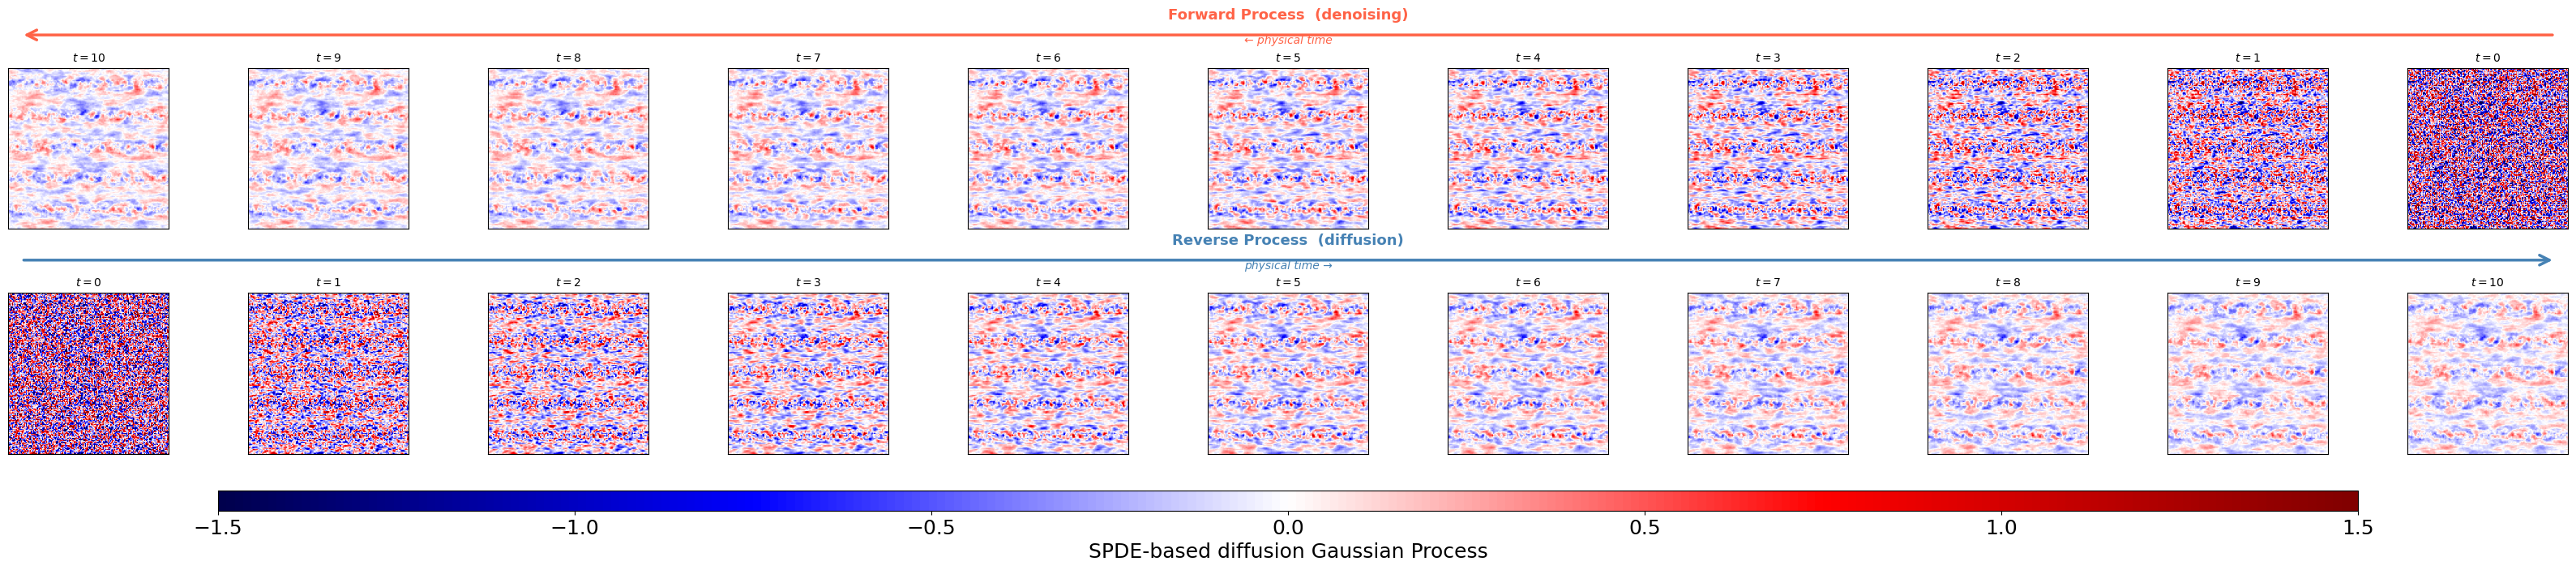

In [25]:
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# Disposition :
#   Rangée 0  (haut)  → Reverse  : solver va de t=T vers t=0
#                                   temps physique va de t=T ← t=0  (flèche gauche)
#   Rangée 1  (bas)   → Forward  : solver va de t=0 vers t=T
#                                   temps physique va de t=0 → t=T  (flèche droite)
#
# Les colonnes sont indexées 0..nsteps dans le sens du SOLVER pour chaque rangée.
# Forward (solver) : col 0 = t=0, col nsteps = t=T  → titres t=0..T de gauche à droite
# Reverse (solver) : col 0 = t=T, col nsteps = t=0  → titres t=T..0 de gauche à droite
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, nsteps + 1,
                         figsize=(3 * (nsteps + 1), 7),
                         constrained_layout=False)
fig.subplots_adjust(left=0.01, right=0.99, top=0.80, bottom=0.12,
                    hspace=0.40, wspace=0.08)

# ── Forward process (rangée 1) ────────────────────────────────────────────────
# Z_all[0] = x_0 (bruit blanc), Z_all[nsteps] = x_T (diffusé)
for col in range(nsteps + 1):
    ax = axes[1, col]
    ax.imshow(Z_all[col].detach().numpy().reshape(nx, ny),
              vmin=-1.5, vmax=1.5, cmap=plt.cm.seismic)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'$t={col}$', fontsize=10)

# ── Reverse process (rangée 0) ────────────────────────────────────────────────
# Z_all_rev[0] = x_T (départ du reverse = fin du forward)
# Z_all_rev[nsteps] = x_0 reconstruit (bruit blanc)
# → on affiche col 0 = t=T  ..  col nsteps = t=0
for col in range(nsteps + 1):
    ax = axes[0, col]
    im = ax.imshow(Z_all_rev[col].detach().numpy().reshape(nx, ny),
                   vmin=-1.5, vmax=1.5, cmap=plt.cm.seismic)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'$t={nsteps - col}$', fontsize=10)

# ── Flèches et labels au-dessus de chaque rangée ─────────────────────────────
fig.canvas.draw()   # force le calcul des positions

bbox_first_0 = axes[0, 0].get_position()
bbox_last_0  = axes[0, nsteps].get_position()
bbox_first_1 = axes[1, 0].get_position()
bbox_last_1  = axes[1, nsteps].get_position()

x_left  = bbox_first_0.x0 + 0.005
x_right = bbox_last_0.x1  - 0.005

# ── Rangée 0 — Reverse : flèche droite → gauche (temps physique croît à droite)
y0_top = bbox_first_0.y1
arrow_y = y0_top + 0.058
label_y = y0_top + 0.080
sub_y   = y0_top + 0.038

fig.add_artist(mpatches.FancyArrowPatch(
    (x_right, arrow_y), (x_left, arrow_y),
    transform=fig.transFigure, clip_on=False,
    arrowstyle='->', linewidth=2.5, mutation_scale=22, color='tomato'))

fig.text((x_left + x_right) / 2, label_y,
         'Forward Process  (denoising)',
         ha='center', va='bottom', fontsize=13, color='tomato', fontweight='bold')

fig.text((x_left + x_right) / 2, sub_y,
         '← physical time',
         ha='center', va='bottom', fontsize=10, color='tomato', style='italic')

# ── Rangée 1 — Forward : flèche gauche → droite (temps physique croît à droite)
y1_top  = bbox_first_1.y1
arrow_y1 = y1_top + 0.058
label_y1 = y1_top + 0.080
sub_y1   = y1_top + 0.038

fig.add_artist(mpatches.FancyArrowPatch(
    (x_left, arrow_y1), (x_right, arrow_y1),
    transform=fig.transFigure, clip_on=False,
    arrowstyle='->', linewidth=2.5, mutation_scale=22, color='steelblue'))

fig.text((x_left + x_right) / 2, label_y1,
         'Reverse Process  (diffusion)',
         ha='center', va='bottom', fontsize=13, color='steelblue', fontweight='bold')

fig.text((x_left + x_right) / 2, sub_y1,
         'physical time →',
         ha='center', va='bottom', fontsize=10, color='steelblue', style='italic')

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.10, 0.02, 0.80, 0.035])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('SPDE-based diffusion Gaussian Process', fontsize=18)
plt.savefig("link_diffusion.png", dpi=600, bbox_inches='tight')
plt.show()
